# SupportSense — Data Exploration

## Objective

Explore the raw customer-support dataset before performing any
cleaning, preprocessing, feature engineering, or model training.

Questions:

- What does the dataset contain?
- Is any data missing?
- Are ticket IDs unique?
- How are the target categories distributed?
- What are typical ticket lengths?
- How are priority and sentiment labels distributed?

In [1]:
# Import path handling, plotting, and tabular-data tools.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Point to the raw dataset using the path expected when running from notebooks/.
DATA_PATH = Path("../data/support_tickets.csv")

In [3]:
# Confirm that the expected CSV file is available before loading it.
DATA_PATH.exists()

True

In [4]:
# Load the raw support-ticket records into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

In [5]:
# Preview the first five records to inspect the columns and example values.
df.head()

,ticket_id,created_at,channel,region,text,category,priority,sentiment
0,TKT-1190,2026-03-06 06:00:00,email,GB,"Hi there, My order has not arrived yet. This h...",delivery,high,neutral
1,TKT-1031,2026-03-05 18:00:00,email,GB,"Hi there, I need a copy of my latest invoice. ...",billing,medium,negative
2,TKT-1011,2026-03-26 12:00:00,web_form,CA,"Hey team, I need a copy of my latest invoice. ...",billing,high,negative
3,TKT-1171,2026-05-05 13:00:00,web_form,SG,"Hey team, My delivery is delayed again. This i...",delivery,high,negative
4,TKT-1272,2026-05-23 10:00:00,mobile_app,US,"Hi, Can I upgrade my plan at any time. This ha...",product_inquiry,medium,positive


In [6]:
# Preview the final five records as another quick ingestion check.
df.tail()

,ticket_id,created_at,channel,region,text,category,priority,sentiment
295,TKT-1263,2026-05-11 21:00:00,mobile_app,AU,"Hello support, What payment methods do you acc...",product_inquiry,medium,positive
296,TKT-1285,2026-03-16 23:00:00,mobile_app,SG,"Hello support, What payment methods do you acc...",product_inquiry,low,neutral
297,TKT-1286,2026-01-03 14:00:00,mobile_app,PH,"Hi there, Does the premium plan include team a...",product_inquiry,medium,neutral
298,TKT-1230,2026-06-24 02:00:00,mobile_app,GB,"Good day, My refund has not appeared on my car...",cancellation_refund,low,negative
299,TKT-1221,2026-02-14 23:00:00,web_form,GB,"Good day, I cancelled but I was still charged....",cancellation_refund,medium,neutral


In [7]:
# Inspect a reproducible random sample from across the dataset.
df.sample(5, random_state=42)

,ticket_id,created_at,channel,region,text,category,priority,sentiment
203,TKT-1047,2026-04-01 22:00:00,email,PH,"Good day, The discount code was not applied. T...",billing,high,negative
266,TKT-1142,2026-06-22 21:00:00,mobile_app,PH,"Hi there, The latest update broke dark mode. T...",technical_issue,high,neutral
152,TKT-1283,2026-02-28 02:00:00,chat,CA,Can I upgrade my plan at any time. I need this...,product_inquiry,low,positive
9,TKT-1183,2026-03-18 02:00:00,mobile_app,SG,"Hey team, Part of my order is missing. This is...",delivery,medium,negative
233,TKT-1077,2026-03-26 03:00:00,email,SG,"Hey team, My account was disabled unexpectedly...",account_access,high,neutral


In [8]:
# Report the dataset dimensions as (rows, columns).
df.shape

(300, 8)

In [9]:
# Display the column labels as a pandas Index.
df.columns

Index(['ticket_id', 'created_at', 'channel', 'region', 'text', 'category',
       'priority', 'sentiment'],
      dtype='str')

In [10]:
# Convert the column labels to a plain Python list for easier reading.
df.columns.tolist()

['ticket_id',
 'created_at',
 'channel',
 'region',
 'text',
 'category',
 'priority',
 'sentiment']

In [11]:
# Check how pandas represented each column after CSV ingestion.
df.dtypes

ticket_id     str
created_at    str
channel       str
region        str
text          str
category      str
priority      str
sentiment     str
dtype: object

In [12]:
# Summarize column types, non-null counts, and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ticket_id   300 non-null    str  
 1   created_at  300 non-null    str  
 2   channel     300 non-null    str  
 3   region      300 non-null    str  
 4   text        300 non-null    str  
 5   category    300 non-null    str  
 6   priority    300 non-null    str  
 7   sentiment   300 non-null    str  
dtypes: str(8)
memory usage: 18.9 KB


In [13]:
# Mark every missing value to inspect the row-level missingness pattern.
df.isna()

,ticket_id,created_at,channel,region,text,category,priority,sentiment
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False


In [14]:
# Count missing values in each column.
df.isna().sum()

ticket_id     0
created_at    0
channel       0
region        0
text          0
category      0
priority      0
sentiment     0
dtype: int64

In [15]:
# Count ticket texts that are empty after surrounding whitespace is removed.
df["text"].str.strip().eq("").sum()

np.int64(0)

In [16]:
# Count distinct ticket identifiers.
df["ticket_id"].nunique()

300

In [17]:
# Count all records so the total can be compared with the unique-ID count.
len(df)

300

In [18]:
# Count repeated ticket IDs; zero means every ticket has a unique identifier.
df["ticket_id"].duplicated().sum()

np.int64(0)

In [19]:
# Count rows that are exact duplicates across every column.
df.duplicated().sum()

np.int64(0)

In [20]:
# Count repeated ticket messages, even when other fields differ.
df["text"].duplicated().sum()

np.int64(1)

In [21]:
# Count the distinct support categories.
df["category"].nunique()

6

In [22]:
# Display category labels in their order of first appearance.
df["category"].unique()

<StringArray>
[           'delivery',             'billing',     'product_inquiry',
 'cancellation_refund',     'technical_issue',      'account_access']
Length: 6, dtype: str

In [23]:
# Sort the category labels alphabetically for a stable reference list.
sorted(df["category"].unique())

['account_access',
 'billing',
 'cancellation_refund',
 'delivery',
 'product_inquiry',
 'technical_issue']

In [24]:
# Count the tickets assigned to each target category.
category_counts = df["category"].value_counts()

category_counts

category
delivery               50
billing                50
product_inquiry        50
cancellation_refund    50
technical_issue        50
account_access         50
Name: count, dtype: int64

In [25]:
# Convert category frequencies to percentages of all tickets.
category_percentages = df["category"].value_counts(normalize=True).mul(100)

category_percentages

category
delivery               16.666667
billing                16.666667
product_inquiry        16.666667
cancellation_refund    16.666667
technical_issue        16.666667
account_access         16.666667
Name: proportion, dtype: float64

In [26]:
# Count the number of distinct category frequencies to test class balance.
category_counts.nunique()

1

In [27]:
# Sort category counts alphabetically so the chart order is deterministic.
category_counts = df["category"].value_counts().sort_index()

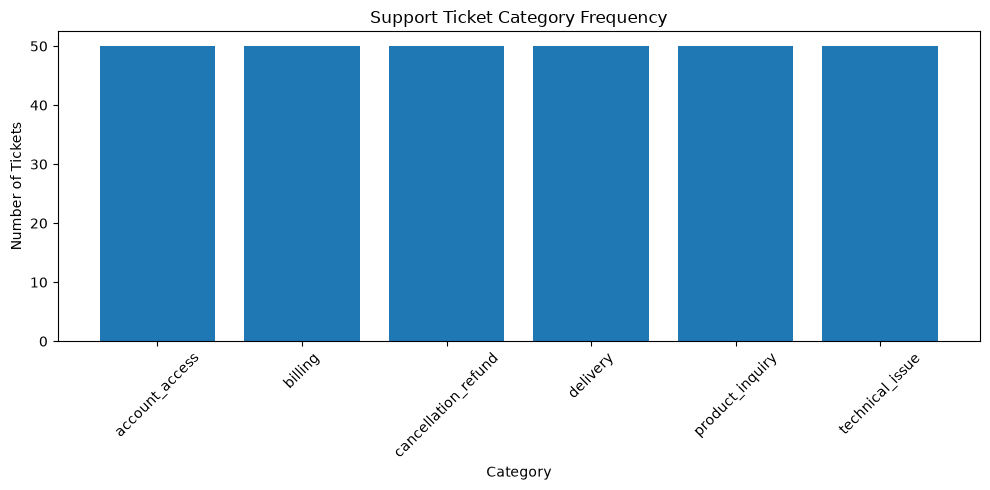

In [28]:
# Visualize the balanced category frequencies in a labeled bar chart.
plt.figure(figsize=(10, 5))

plt.bar(category_counts.index, category_counts.values)

plt.title("Support Ticket Category Frequency")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# Count tickets at each priority level.
priority_counts = df["priority"].value_counts()

priority_counts

priority
medium    134
high      110
low        56
Name: count, dtype: int64

In [30]:
# Express the priority distribution as percentages of all tickets.
df["priority"].value_counts(normalize=True).mul(100)

priority
medium    44.666667
high      36.666667
low       18.666667
Name: proportion, dtype: float64

In [31]:
# Reindex priority counts from low to high for a meaningful display order.
priority_order = ["low", "medium", "high"]

priority_counts = df["priority"].value_counts().reindex(priority_order)

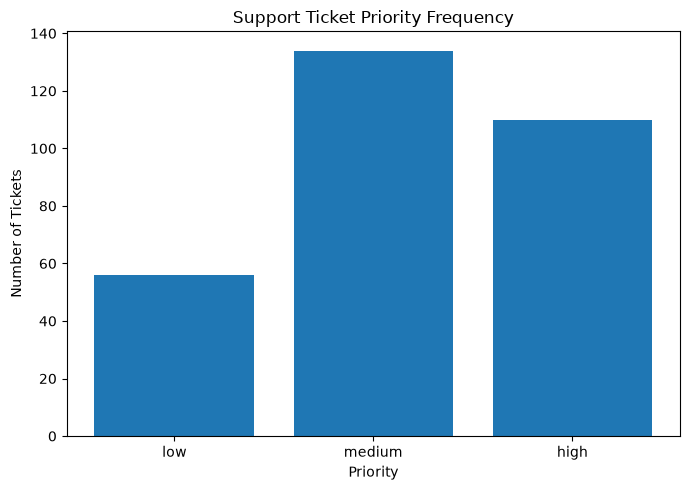

In [32]:
# Plot ticket counts for the ordered priority levels.
plt.figure(figsize=(7, 5))

plt.bar(
    priority_counts.index,
    priority_counts.values,
)

plt.title("Support Ticket Priority Frequency")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

In [33]:
# Count tickets assigned to each sentiment label.
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts

sentiment
neutral     157
negative    123
positive     20
Name: count, dtype: int64

In [34]:
# Reindex sentiment counts from negative through positive for display.
sentiment_order = ["negative", "neutral", "positive"]

sentiment_counts = df["sentiment"].value_counts().reindex(sentiment_order)

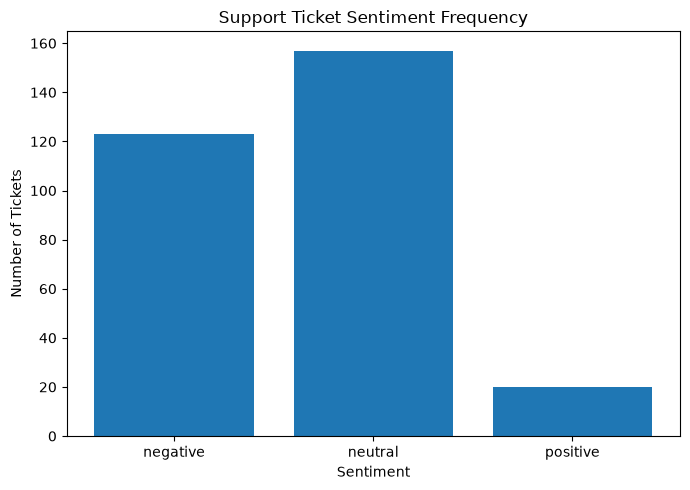

In [35]:
# Plot the ordered sentiment-label distribution.
plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
)

plt.title("Support Ticket Sentiment Frequency")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

In [36]:
# Work on a copy so exploratory features do not alter the raw DataFrame.
analysis_df = df.copy()

In [37]:
# Measure each ticket's length in characters.
analysis_df["character_count"] = analysis_df["text"].str.len()

In [38]:
# Estimate each ticket's word count by splitting its text on whitespace.
analysis_df["word_count"] = analysis_df["text"].str.split().str.len()

In [39]:
# Calculate the average number of characters per ticket.
analysis_df["character_count"].mean()

np.float64(103.44)

In [40]:
# Calculate the average number of whitespace-delimited words per ticket.
analysis_df["word_count"].mean()

np.float64(19.24)

In [41]:
# Summarize the center, spread, and range of both length measures.
analysis_df[["character_count", "word_count"]].describe()

,character_count,word_count
count,300.000000,300.000000
mean,103.440000,19.240000
std,20.685891,4.207304
min,47.000000,8.000000
25%,87.000000,16.000000
50%,106.000000,19.000000
75%,119.000000,22.000000
max,161.000000,32.000000


In [42]:
# Locate the row containing the shortest ticket by word count.
shortest_index = analysis_df["word_count"].idxmin()

In [43]:
# Inspect the shortest ticket and its two length measurements.
analysis_df.loc[
    shortest_index,
    ["ticket_id", "text", "word_count", "character_count"],
]

ticket_id                                                 TKT-1156
text               Hey team, The box arrived damaged. Please help.
word_count                                                       8
character_count                                                 47
Name: 67, dtype: object

In [44]:
# Locate the row containing the longest ticket by word count.
longest_index = analysis_df["word_count"].idxmax()

In [45]:
# Inspect the longest ticket and its two length measurements.
analysis_df.loc[
    longest_index,
    ["ticket_id", "text", "word_count", "character_count"],
]

ticket_id                                                   TKT-1198
text               Hello support, The courier marked the package ...
word_count                                                        32
character_count                                                  161
Name: 286, dtype: object

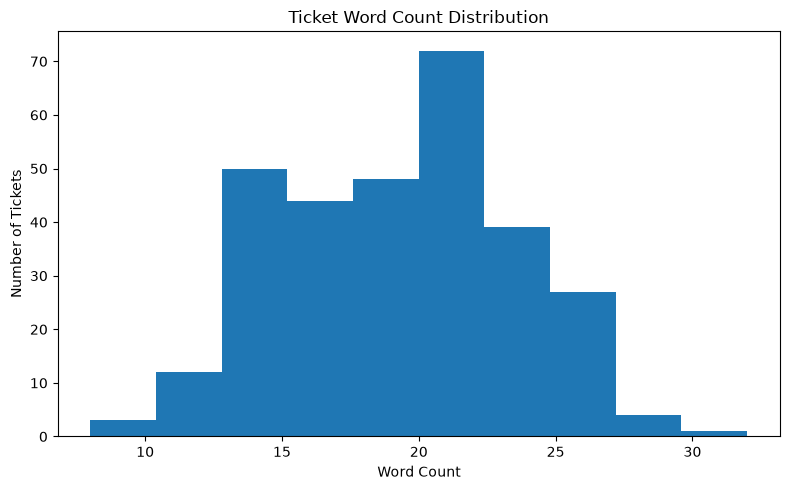

In [46]:
# Plot the distribution of ticket lengths measured in words.
plt.figure(figsize=(8, 5))

plt.hist(
    analysis_df["word_count"],
    bins=10,
)

plt.title("Ticket Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

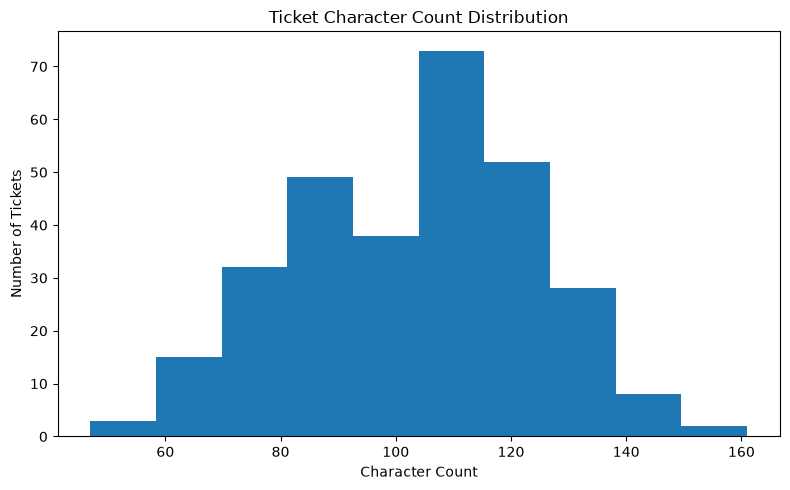

In [47]:
# Plot the distribution of ticket lengths measured in characters.
plt.figure(figsize=(8, 5))

plt.hist(
    analysis_df["character_count"],
    bins=10,
)

plt.title("Ticket Character Count Distribution")
plt.xlabel("Character Count")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

In [48]:
# Count tickets submitted through each support channel.
df["channel"].value_counts()

channel
chat          79
mobile_app    76
email         73
web_form      72
Name: count, dtype: int64

In [49]:
# Count tickets originating from each region.
df["region"].value_counts()

region
PH    58
SG    53
GB    52
CA    51
AU    49
US    37
Name: count, dtype: int64

In [50]:
# Review every categorical label, including missing values if any appear.
categorical_columns = [
    "channel",
    "region",
    "category",
    "priority",
    "sentiment",
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


channel
channel
chat          79
mobile_app    76
email         73
web_form      72
Name: count, dtype: int64

region
region
PH    58
SG    53
GB    52
CA    51
AU    49
US    37
Name: count, dtype: int64

category
category
delivery               50
billing                50
product_inquiry        50
cancellation_refund    50
technical_issue        50
account_access         50
Name: count, dtype: int64

priority
priority
medium    134
high      110
low        56
Name: count, dtype: int64

sentiment
sentiment
neutral     157
negative    123
positive     20
Name: count, dtype: int64


## Exploration Summary

### Dataset size

The dataset contains **300 customer-support tickets** and **8 columns**: `ticket_id`, `created_at`, `channel`, `region`, `text`, `category`, `priority`, and `sentiment`. All columns currently load as strings, so `created_at` still needs to be converted to a datetime type during preprocessing.

### Missing data

No null values were found in any column, and no ticket has an empty or whitespace-only `text` value.

### Ticket identifiers

All **300 ticket IDs are unique**. There are no duplicated ticket IDs and no rows duplicated across every column, so each row has a distinct identifier and record. The ID should be retained for traceability but excluded from predictive features.

### Category distribution

There are six target categories: `account_access`, `billing`, `cancellation_refund`, `delivery`, `product_inquiry`, and `technical_issue`. Each contains exactly **50 tickets (16.67%)**, so the category target is perfectly balanced.

### Priority distribution

`medium` is the most common priority with **134 tickets (44.67%)**, followed by `high` with **110 (36.67%)** and `low` with **56 (18.67%)**. The priority labels are moderately imbalanced, with low-priority tickets least represented.

### Sentiment distribution

`neutral` is the most common sentiment with **157 tickets (52.33%)**, followed by `negative` with **123 (41.00%)** and `positive` with only **20 (6.67%)**. Sentiment is substantially imbalanced, especially for the positive class.

### Ticket length

Tickets average **103.44 characters** and **19.24 whitespace-delimited words**. The medians are 106 characters and 19 words; the middle 50% spans 87–119 characters and 16–22 words. Overall lengths range from 47–161 characters and 8–32 words, so the messages are consistently short.

### Data-quality observations

There are no fully duplicated rows, but one ticket body appears twice: `TKT-1184` and `TKT-1159` have identical text. Both are labeled `delivery` with `neutral` sentiment, but their priority labels conflict (`high` versus `low`). This could be a legitimate repeated request or inconsistent labeling and should be reviewed before splitting the data.

The perfectly even category counts may indicate deliberate sampling or synthetic generation, so the dataset's provenance should be confirmed. Also, `created_at` is still stored as text rather than as a datetime value.

### Questions for preprocessing

- Should the duplicated ticket text be retained, removed, or grouped so its copies cannot fall into different data splits?
- Are there normalized or near-duplicate messages that the exact, case-sensitive duplicate check did not detect?
- Should `created_at` be parsed and used for temporal features or a time-based evaluation split?
- Which fields are prediction targets, and which can safely be used as features without label leakage?
- Should stratification, class weighting, or resampling be used if priority or sentiment is predicted?
- What text normalization will reduce noise without removing wording or punctuation that conveys sentiment or urgency?